# Luke Camilleri - Interpretable AI project

#### Task 1: Data Preproccessing

In [1]:
# importing dataset
from ucimlrepo import fetch_ucirepo 
import pandas as pd

# fetch dataset 
bank_marketing = fetch_ucirepo(id=222) 
  
# data (as pandas dataframes) 
X = bank_marketing.data.features 
y = bank_marketing.data.targets 
  
# metadata 
#print(bank_marketing.metadata) 
  
# variable information 
#print(bank_marketing.variables) 

# making preprocessing easier
df = pd.concat([X, y], axis = 1)
df.head()

# remove duration
df= df.drop(columns= ['duration'])

# columns which needed to be encoded as they are categorical
categorical_cols = [
    "job", "marital", "education", "default", "housing",
    "loan", "contact", "month", "poutcome"
]

# onw hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True) # drop_first is used to avoid multicollinearity

df_encoded.info()
df_encoded.head()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 38 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   age                  45211 non-null  int64
 1   balance              45211 non-null  int64
 2   day_of_week          45211 non-null  int64
 3   campaign             45211 non-null  int64
 4   pdays                45211 non-null  int64
 5   previous             45211 non-null  int64
 6   y                    45211 non-null  str  
 7   job_blue-collar      45211 non-null  bool 
 8   job_entrepreneur     45211 non-null  bool 
 9   job_housemaid        45211 non-null  bool 
 10  job_management       45211 non-null  bool 
 11  job_retired          45211 non-null  bool 
 12  job_self-employed    45211 non-null  bool 
 13  job_services         45211 non-null  bool 
 14  job_student          45211 non-null  bool 
 15  job_technician       45211 non-null  bool 
 16  job_unemployed       45211 non-nu

,age,balance,day_of_week,campaign,pdays,previous,y,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success
0,58,2143,5,1,-1,0,no,False,False,False,...,False,False,False,False,True,False,False,False,False,False
1,44,29,5,1,-1,0,no,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,33,2,5,1,-1,0,no,False,True,False,...,False,False,False,False,True,False,False,False,False,False
3,47,1506,5,1,-1,0,no,True,False,False,...,False,False,False,False,True,False,False,False,False,False
4,33,1,5,1,-1,0,no,False,False,False,...,False,False,False,False,True,False,False,False,False,False


### Task 2: Interpreting White-Box Models 

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# this is done because we need to predict duration and in the first task we removed duration so we have to get the original dataset 
bank_marketing = fetch_ucirepo(id=222)

df2 = pd.concat([
    bank_marketing.data.features,
    bank_marketing.data.targets
], axis=1)

# one hot encoding
df2_encoded = pd.get_dummies(df2, columns=categorical_cols, drop_first=True)

X_duration = df2_encoded.drop(columns=["duration", "y"])# this holds all the features except duration, y is removed has it holds strings. X only holds numerical features
y_duration = df2_encoded["duration"] # this holds the duration column which is the target

# splitting data
X_train, X_test, y_train, y_test = train_test_split(X_duration, y_duration, test_size=0.2, random_state=42)

# train the model
linear_reg = LinearRegression() # this is an empty model which will be trained 
linear_reg.fit(X_train, y_train) # takes the empyt model and starts training

coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": linear_reg.coef_
}).sort_values(by="Coefficient", ascending=False)

coefficients.head(10)


,Feature,Coefficient
36,poutcome_success,56.724869
15,job_unemployed,51.318892
10,job_retired,44.978569
11,job_self-employed,28.047673
25,month_dec,27.753308
7,job_entrepreneur,24.392877
6,job_blue-collar,24.243586
12,job_services,19.035330
8,job_housemaid,14.308721
14,job_technician,11.367407


#####  The linear regression model estimates the expected call duration as an additive combination of all features. Each coefficient represents the expected change in call duration associated with a one‑unit increase in that feature, holding all other features constant. Because categorical variables were one‑hot encoded, each dummy‑variable coefficient measures the difference in expected duration relative to the reference category (the category dropped by drop_first=True).

##### Positive coefficients indicate that the feature increases the predicted duration, while negative coefficients would indicate a decrease. The largest positive coefficient is poutcome_success (+56.7 seconds), meaning that clients who previously responded positively to a marketing campaign tend to stay significantly longer on the phone compared to the reference outcome. Several job categories also show strong positive effects: unemployed (+51.3 seconds), retired (+45.0 seconds), and self‑employed (+28.0 seconds) clients all have longer expected call durations than the reference job category. Seasonal effects are also present, with calls made in December lasting approximately 27.8 seconds longer than those in the reference month.

##### Overall, the coefficients reveal clear behavioural patterns: clients with more free time (unemployed, retired) or prior positive engagement tend to have longer conversations, and certain months are associated with increased call duration. Because each coefficient has a clear, direct interpretation, this model is fully transparent and aligns with the definition of a white‑box model.

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X_except_y =  df_encoded.drop(columns=["y"])   # all features except the target
y_target= df_encoded["y"] # the target variable

# splitting data
X_train, X_test, y_train, y_test = train_test_split(X_except_y, y_target, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=2000)
log_reg.fit(X_train_scaled, y_train)


log_coeffs = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_reg.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print("Top 10 POSITIVE coefficients (increase P(y = yes)):")
print(log_coeffs.head(10).to_string(index=False))
print("\nTop 10 NEGATIVE coefficients (decrease P(y = yes)):")
print(log_coeffs.tail(10).to_string(index=False))

Top 10 POSITIVE coefficients (increase P(y = yes)):
            Feature  Coefficient
   poutcome_success     0.409271
 education_tertiary     0.154078
          month_mar     0.100317
        job_retired     0.081781
education_secondary     0.075528
     poutcome_other     0.065125
          month_oct     0.061940
              pdays     0.061467
     marital_single     0.059939
          month_sep     0.052115

Top 10 NEGATIVE coefficients (decrease P(y = yes)):
    Feature  Coefficient
  month_feb    -0.126715
   loan_yes    -0.149546
  month_jan    -0.202182
  month_nov    -0.248020
  month_jul    -0.252797
   campaign    -0.260530
  month_jun    -0.263300
  month_aug    -0.285288
housing_yes    -0.301618
  month_may    -0.473183


#### In the logistic regression model, each coefficient represents the change in the log-odds of predicting "y = yes" associated with a one standard deviation increase in the feature, holding all other features constant. Features were standardised before fitting for two reasons: to fix a convergence issue that affected the unscaled version, and to put all coefficients on a comparable scale so continuous features (such as balance or age) can be compared directly against one-hot encoded dummy variables. Dummy-variable coefficients still measure the effect relative to the dropped reference category.

#### Among the positive predictors, poutcome_success remains by far the strongest driver (+0.41), confirming that clients who previously responded successfully to a campaign are much more likely to subscribe again. Education level also plays a clear role, with both tertiary (+0.15) and secondary (+0.08) education increasing the probability of subscription relative to primary education. Contacts made in March (+0.10), October (+0.06), and September (+0.05) are associated with higher subscription likelihood compared to the reference month, while being retired (+0.08), single (+0.06), and having a recent previous contact (pdays, +0.06) all push the probability upward. A prior campaign outcome of "other" (+0.07) also carries a modest positive effect.

#### On the negative side, seasonality emerges as the dominant factor. Calls placed in May (–0.47) are associated with the largest drop in subscription probability, followed by August (–0.29), June (–0.26), July (–0.25), November (–0.25), January (–0.20), and February (–0.13). This pattern likely reflects campaign volume — May is the busiest contact month in the dataset, so per-call engagement is lower. Financial obligations also hurt: having a housing loan (–0.30) or personal loan (–0.15) reduces the probability of subscription, which is intuitive given that clients servicing debt are less able to commit additional funds to a term deposit. Finally, the number of contacts within the current campaign (campaign, –0.26) has a clear negative effect, consistent with diminishing returns and client fatigue from repeated calls.

#### Overall, the scaled logistic regression provides a transparent and directly comparable view of how each feature influences subscription probability. Prior engagement, education, and demographic stability push probabilities up, while existing debt, high contact frequency, and certain busy months push them down — a coherent behavioural story that is consistent with the insights later recovered from the Random Forest analysis.

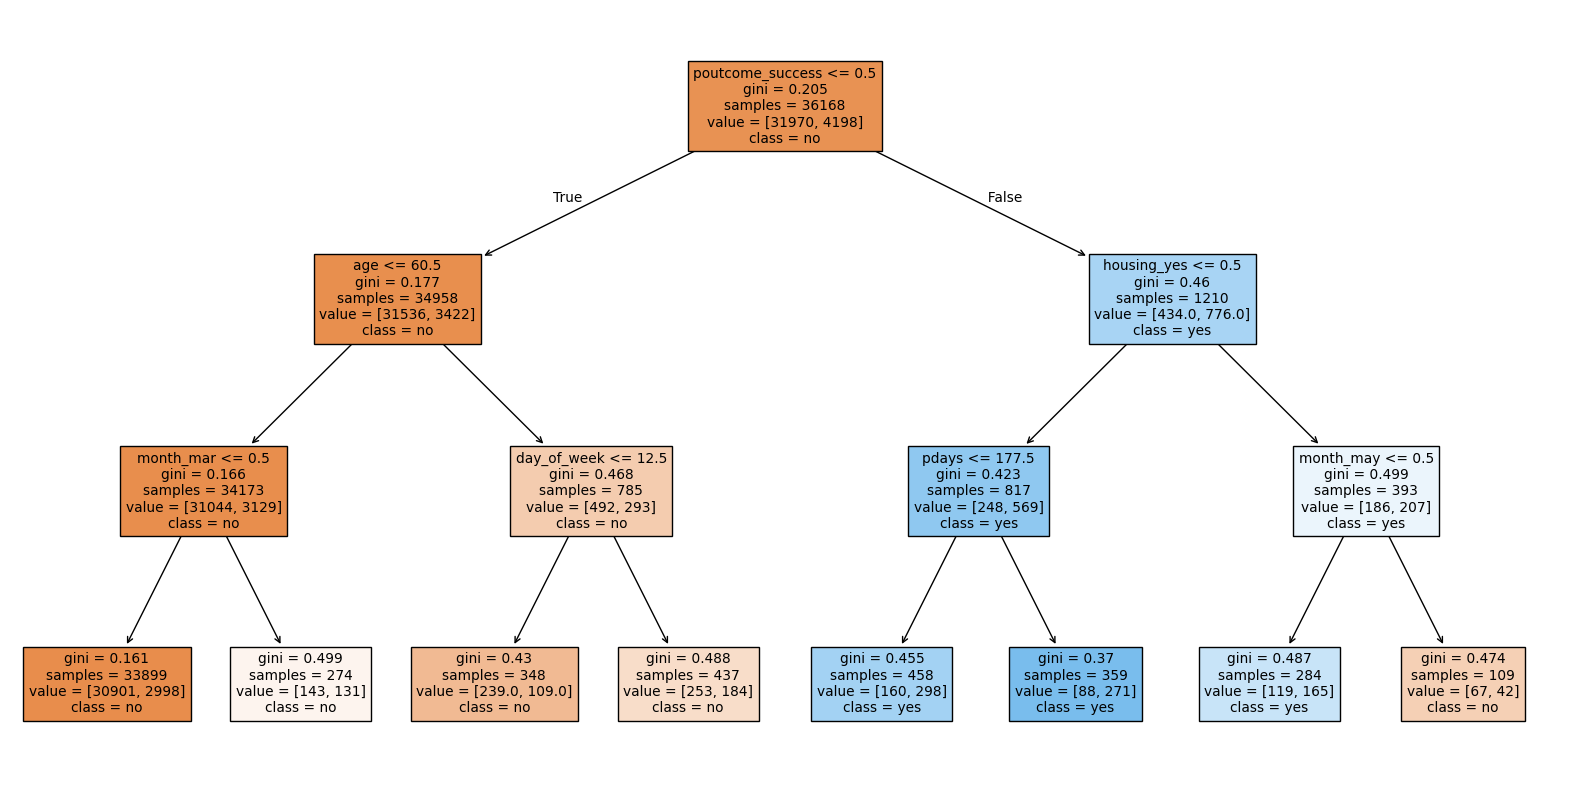

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt


X = df_encoded.drop(columns=["y"])
y = df_encoded["y"] # target variable

clf_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
clf_tree.fit(X_train, y_train)


plt.figure(figsize=(20,10))
tree.plot_tree(
    clf_tree,
    feature_names=X.columns,
    class_names=["no", "yes"],
    filled=True
)
plt.show()


#### The decision tree (depth = 3) predicts the binary outcome y by making a sequence of at most three decisions. The first and most important split is on poutcome_success, indicating that the outcome of the previous marketing campaign is the strongest predictor of subscription. Clients with a previously successful outcome are directed to the right branch, where additional splits on housing_yes and pdays identify groups with high likelihood of subscribing. In particular, clients with previous success, no housing loan, and low pdays values form a leaf with a strong majority of “yes” outcomes.

#### On the left branch, representing clients without previous success, the tree next splits on age and month. Clients aged 60 or below and contacted outside of March form a very pure “no” region, indicating low subscription probability. Other branches, such as those involving March contacts or older clients, show more mixed class distributions.

#### Overall, the tree highlights clear behavioural patterns: previous campaign success is the dominant factor, followed by financial indicators (housing loan), recency of contact (pdays), and seasonal effects (month). The resulting model is fully interpretable, providing transparent rule‑based predictions consistent with the definition of a white‑box classifier.

### Task 3: Interpreting Random Forest Using Feature Importance

In [5]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42)

rf.fit(X_train, y_train) # trains the random forest 

feature_importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_ # displays the importance of each feature
}).sort_values(by="Importance", ascending=False) # most important first 
feature_importances.head(10)

,Feature,Importance
1,balance,0.190571
0,age,0.159822
2,day_of_week,0.138233
3,campaign,0.064011
36,poutcome_success,0.058073
4,pdays,0.056308
5,previous,0.030802
21,housing_yes,0.021481
18,education_secondary,0.018618
14,job_technician,0.015269


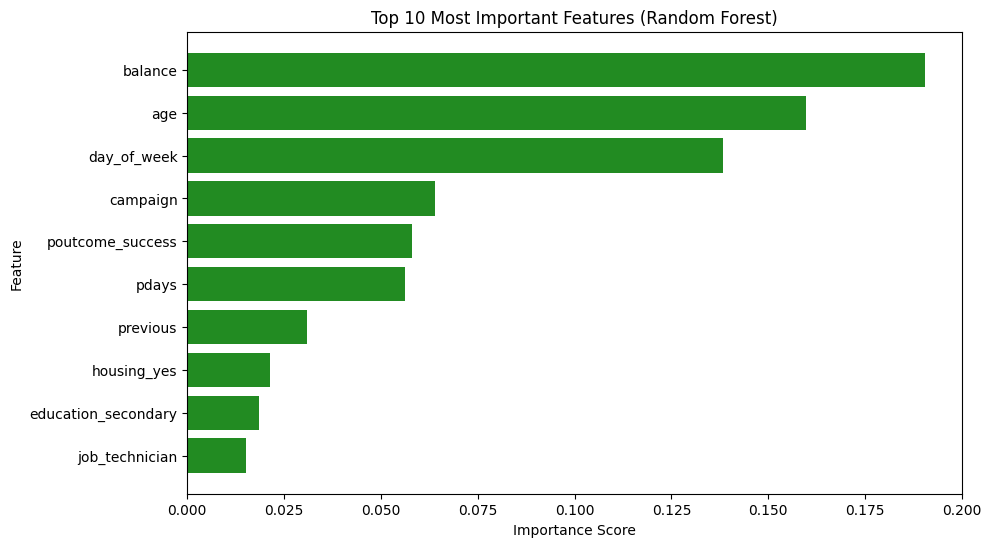

In [6]:
# visualisation of feature importance
plt.figure(figsize=(10,6))
plt.barh(feature_importances["Feature"].head(10), 
         feature_importances["Importance"].head(10),
         color="forestgreen")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features (Random Forest)")
plt.gca().invert_yaxis()  # highest importance at the top
plt.show()


#### The Random Forest classifier provides an importance score for each feature, indicating how much it contributes to reducing impurity across all trees in the ensemble. The bar chart visualises the top 10 most influential features, allowing us to clearly identify which variables play the largest role in predicting the response variable y.

#### The most important feature is balance, suggesting that clients’ account balances strongly influence their likelihood of subscribing. This may reflect financial stability or spending behaviour that correlates with interest in long‑term deposits. Age is the second most important feature, indicating that subscription behaviour varies significantly across age groups. The day_of_week feature also appears highly influential, implying that the timing of contact affects client responsiveness.

#### Other important features include campaign (number of contacts during the current campaign), poutcome_success (previous campaign success), and pdays (recency of previous contact). These features capture behavioural and historical patterns in client interactions. Lower‑ranked features such as housing_yes, education_secondary, and job_technician still contribute to the model but have a smaller overall impact.

#### Overall, the feature importance plot highlights that financial indicators (balance), demographic factors (age), and contact‑related variables (day_of_week, campaign, pdays) are the strongest predictors of subscription. This provides a clear, interpretable summary of the key drivers identified by the Random Forest model.

### Task 4: Permutation Feature Importance

In [7]:
from sklearn.inspection import permutation_importance

result = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1) # test is used instead of train as permutation importance needs unseen data

perm_importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": result.importances_mean
}).sort_values(by="Importance", ascending=False)

perm_importances.head(10)

,Feature,Importance
36,poutcome_success,0.012297
4,pdays,0.004047
2,day_of_week,0.003373
30,month_mar,0.002919
21,housing_yes,0.002709
0,age,0.001847
3,campaign,0.001272
33,month_oct,0.001272
1,balance,0.001128
5,previous,0.001095


#### The traditional Random Forest feature importance (based on Gini impurity reduction) and the permutation feature importance produce similar but not identical rankings. The traditional method ranked balance and age as the most important features, largely because continuous variables tend to create large impurity reductions and are frequently selected for splits. However, permutation importance reveals that shuffling balance causes only a small drop in accuracy, suggesting that its predictive value is lower than the traditional method implies.

#### In contrast, poutcome_success becomes the most important feature under permutation importance. This indicates that previous campaign success has a strong effect on model performance, even though it is a binary variable and therefore receives less emphasis in impurity based importance. Features such as pdays, day_of_week, and housing_yes appear near the top in both methods, confirming their genuine predictive influence.

#### Permutation importance also highlights the relevance of specific months (for example, month_mar and month_oct), which do not appear prominently in the traditional ranking. This occurs because one hot encoded categorical variables often have small individual impurity reductions but still meaningfully affect predictions when perturbed.

#### Overall, the comparison shows that traditional feature importance can over value continuous variables and under value binary or one hot encoded features, while permutation importance provides a more reliable, model agnostic assessment of how each feature contributes to predictive accuracy.

### Task 5:  Model-Agnostic Interpretation Methods

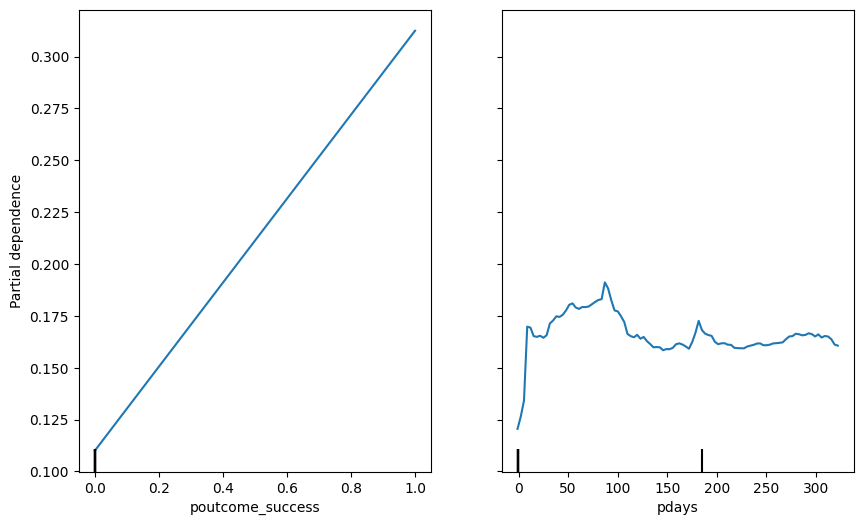

In [8]:
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(
    rf,
    X_test.astype(float), # converts the test set into float 
    ["poutcome_success", "pdays"], # chosen features 
    ax=ax
)

plt.show()


#### Partial Dependence Plots (PDPs) were generated for two important features: poutcome_success and pdays. PDPs show how the model’s predicted probability changes as each feature varies, while averaging out the influence of all other variables. This makes them a powerful tool for interpreting the behaviour of a complex model such as a Random Forest.

#### The PDP for poutcome_success shows a clear positive jump in predicted probability when the previous campaign was successful. When poutcome_success = 0, the partial dependence is low, but when it switches to 1, the predicted probability increases sharply. This indicates that clients who subscribed in the past are significantly more likely to subscribe again, confirming the strong behavioural influence captured by the model. The simple two point structure reflects the binary nature of the feature.

#### The PDP for pdays reveals a non linear relationship. When pdays is close to zero (meaning the client was contacted very recently), the predicted probability of subscription is higher. As pdays increases, the predicted probability decreases and then stabilises, with some fluctuations caused by the Random Forest’s non linear decision boundaries. This suggests that recency of previous contact plays an important role in the model’s predictions: clients contacted recently are more responsive, while those contacted a long time ago are less likely to subscribe.

#### Together, these PDPs help interpret the Random Forest by showing not only which features matter, but how they influence predictions. They reveal both the direction (positive or negative effect) and the shape (linear or non linear) of each feature’s relationship with the target, providing insight into the model’s internal logic in a way that complements feature importance scores.

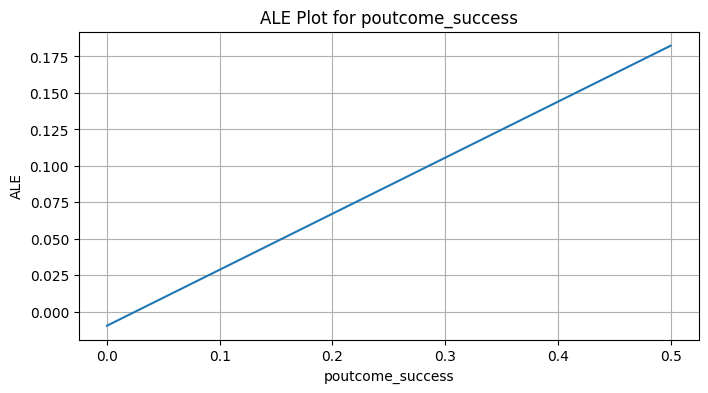

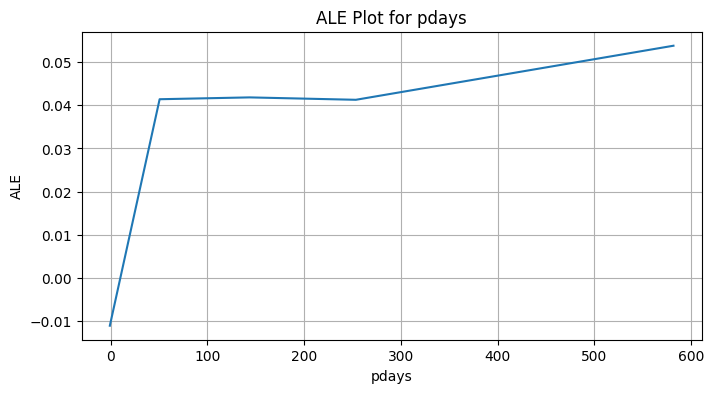

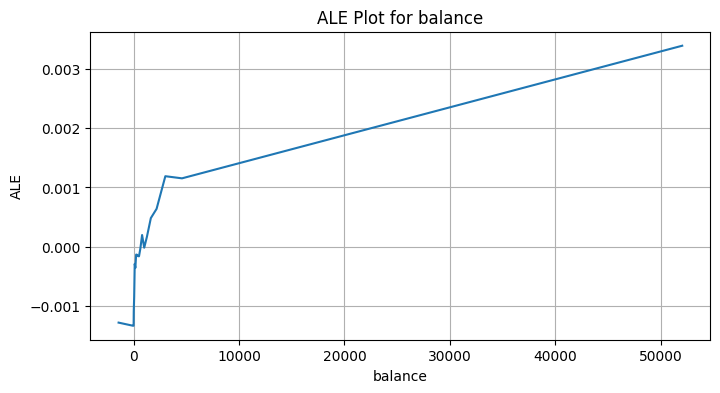

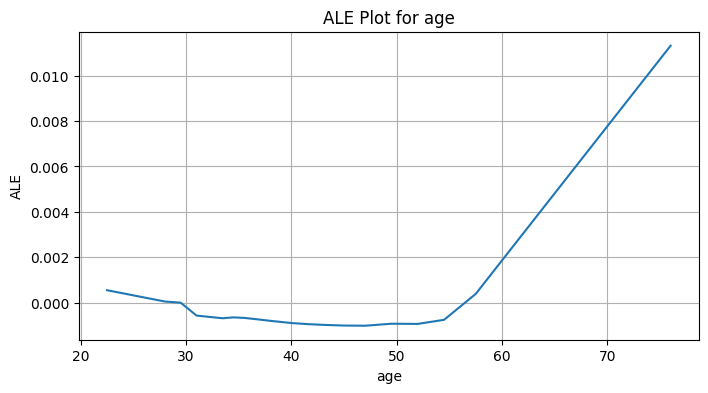

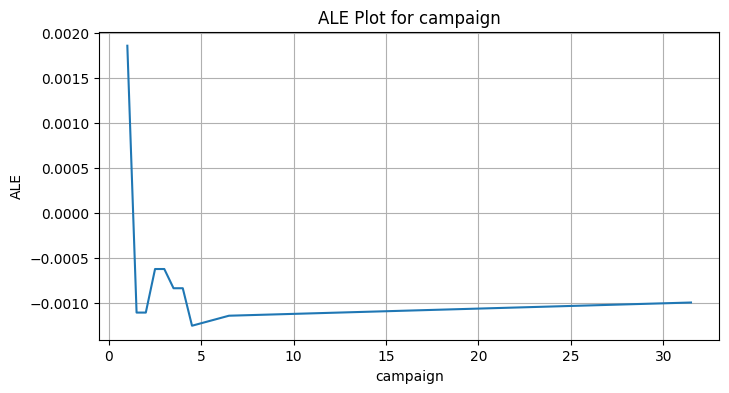

In [9]:
import numpy as np

# convert to float for ALE 
X_ale = X_test.copy()

# Convert bool to  float
bool_cols = X_ale.select_dtypes('bool').columns
X_ale[bool_cols] = X_ale[bool_cols].astype(float)

# Convert int to float
int_cols = X_ale.select_dtypes('int').columns
X_ale[int_cols] = X_ale[int_cols].astype(float)

# this is done because pandas does not allow inserting floats into int or bool columns

# ALE function 
def ale_1d(model, X, feature, bins=20):
    # extravt the feature values
    x = X[feature].values.astype(float)
    quantiles = np.quantile(x, np.linspace(0, 1, bins + 1)) # splits the feature range into quantile bins
    # quantiles are used as each bin has enough data, which stabilises the ALE estimate 

    # computing local effects
    mids = 0.5 * (quantiles[:-1] + quantiles[1:]) # mid point of bins, to be used later for plotting
    effects = [] # stores the local effect in each bin

    # loops through bin 
    for i in range(bins):
        # identifies the rose whose feauture values fall inside the current bin 
        lower = quantiles[i]
        upper = quantiles[i+1]

        idx = (x >= lower) & (x < upper)

        # if no sample falls in the bin, simple add 0 (no effect)
        if idx.sum() == 0:
            effects.append(0)
            continue
        
        # pertubing the feature locally
        X_low = X.copy() 
        X_high = X.copy()

        X_low.loc[idx, feature] = lower 
        X_high.loc[idx, feature] = upper

        # computing local effect 
        pred_low = model(X_low) # predictions when the feature is set to the lower bin
        pred_high = model(X_high) # ... ... .. upper bin 

        effects.append(np.mean(pred_high - pred_low)) # average effect added to the list 

    # accumulating the effects
    ale = np.cumsum(effects) # cumulative sum of local effects
    ale = ale - np.mean(ale) # centered to have mean 0 (standard ALE convention)
    return mids, ale

# wrap model to return probabilities
def model_1d(X):
    return rf.predict_proba(X)[:, 1] # wraps the random forst model to return the probability of the positive class
    # ALE requires a 1 dimensional numeric output, this ensures compatibility 

important_features = [
    "poutcome_success",
    "pdays",
    "balance",
    "age",
    "campaign"
]

# plots
for feature in important_features:
    mids, ale_vals = ale_1d(model_1d, X_ale, feature)# computes the ALE values using thismodel and the dataset

    plt.figure(figsize=(8,4))
    plt.plot(mids, ale_vals)
    plt.xlabel(feature)
    plt.ylabel("ALE")
    plt.title(f"ALE Plot for {feature}")
    plt.grid(True)
    plt.show()


#### To understand how the most influential features affect the model’s predictions, Accumulated Local Effects (ALE) plots were generated for five key variables: poutcome_success, pdays, balance, age, and campaign. ALE plots provide a robust alternative to Partial Dependence Plots (PDPs), especially when features are correlated, because ALE evaluates local changes within the data distribution rather than averaging over potentially unrealistic combinations of feature values. Below is a consolidated interpretation of each feature’s ALE behaviour and a comparison with its corresponding PDP.

### poutcome_success.  
#### The ALE plot shows a strong positive effect when moving from 0 to 1, indicating that clients who previously responded successfully to a marketing campaign have a substantially higher probability of subscribing again. This is the most influential feature in the model. The PDP for this feature shows a similar jump, but ALE is more reliable because it isolates the effect of switching from 0 to 1 while accounting for correlations with other variables such as previous and pdays. Both methods agree on the direction and magnitude of the effect, but ALE avoids extrapolating into unrealistic regions of the feature space.

### pdays.  
#### The ALE curve rises sharply from pdays ≈ 0 to around 50, then stabilises. This initially appears counterintuitive, but it reflects the dataset’s encoding: pdays = -1 (mapped to 0 during preprocessing) means the client was never contacted before, a group that behaves differently from recently contacted clients. The spike around 50–100 days corresponds to genuinely recent contacts, who are more likely to subscribe. PDPs typically show a monotonic decrease (more days since last contact → lower probability), but this masks the special “never contacted” group. ALE reveals this hidden structure and therefore provides a more faithful representation of the feature’s effect.

### balance.  
##### The ALE plot shows a gentle upward trend, indicating that clients with higher account balances are slightly more likely to subscribe. The effect is modest but consistent. PDPs show a similar monotonic increase, but ALE is smoother and less distorted by correlations with job type, education, and age. Both methods broadly agree, though ALE provides a more stable estimate of the local effect.

### age.  
#### The ALE curve dips slightly between ages 30–50 and rises sharply after age 60. This suggests that older clients—particularly retirees—are more likely to subscribe, while younger and middle‑aged clients are less responsive. PDPs show a similar pattern, but ALE is more trustworthy because age is strongly correlated with job category, marital status, and balance. ALE avoids averaging over unrealistic combinations (e.g., “student aged 70”) that PDPs implicitly include.

### campaign.  
#### The ALE plot shows a spike at campaign = 0, a drop for values 2–5, and a gradual return toward zero for higher values. This reflects a well‑known pattern in the Bank Marketing dataset: clients contacted many times within the same campaign are less likely to subscribe, suggesting diminishing returns and potential fatigue from repeated contact. PDPs typically show a monotonic decrease, but ALE reveals the local effect that the first few additional contacts reduce the probability the most. Because campaign is correlated with previous and pdays, ALE provides a more nuanced and reliable interpretation.

### Overall comparison of ALE and PDPs.  
#### PDPs offer a broad, global view of feature influence but can be misleading when features are correlated or contain special values. ALE plots, by contrast, compute local effects within the observed data distribution, avoiding extrapolation and producing more realistic interpretations. In this dataset, ALE provides clearer insights for pdays and campaign, where PDPs obscure important structure, while still aligning with PDPs for more straightforward features such as balance and age. Overall, ALE offers a more accurate and trustworthy understanding of how the model responds to changes in its most important features.

Surrogate R²: 0.5486006202843358


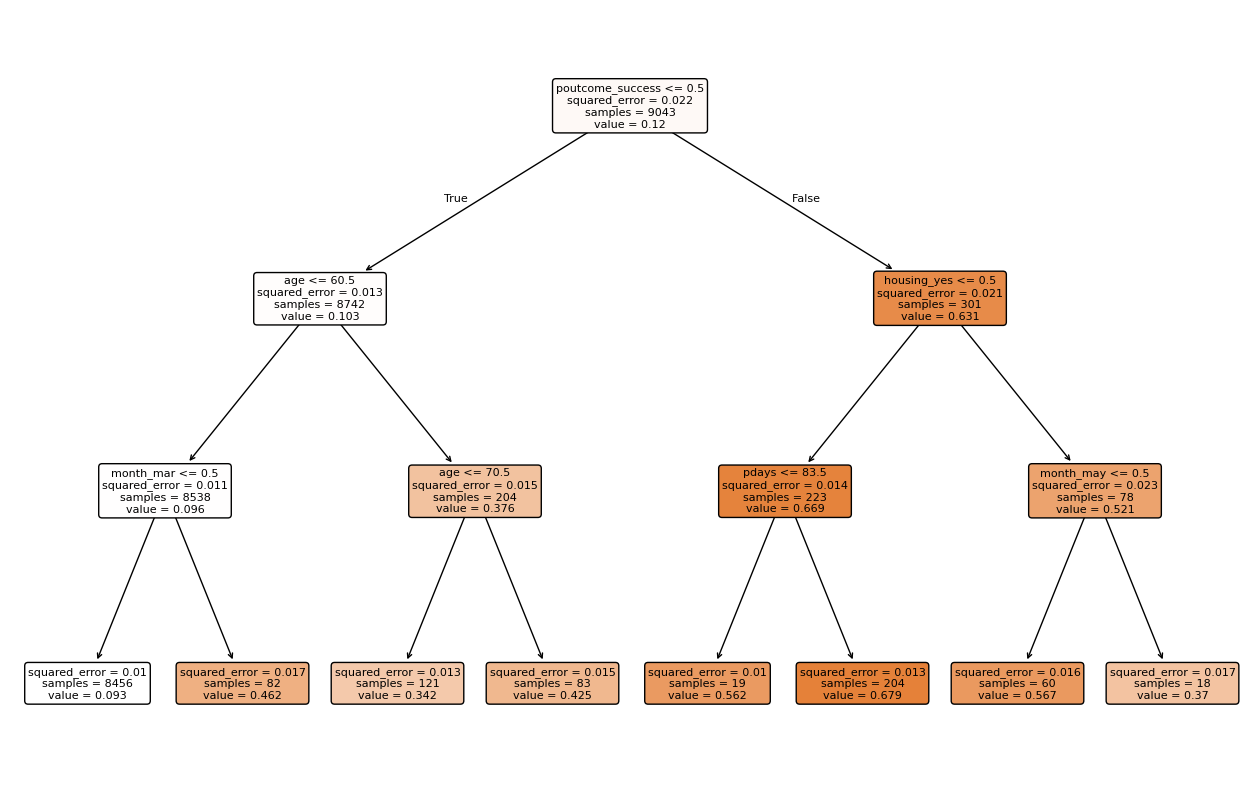

In [10]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn.tree import plot_tree

# Get the Random Forest predictions (probabilities)
rf_preds = rf.predict_proba(X_test)[:, 1] # extracts the probability of the positive class
# probabilities will be become the target for surrogate model

# Fit surrogate model
surrogate = DecisionTreeRegressor(max_depth=3, random_state=42)
surrogate.fit(X_test, rf_preds)# X_test is used for input and rf_predis the output probabilities

# Evaluatation 
surrogate_preds = surrogate.predict(X_test) # surrogate predicts probabilities for test data
r2 = r2_score(rf_preds, surrogate_preds)

print("Surrogate R²:", r2)


plt.figure(figsize=(16,10))
plot_tree(surrogate, feature_names=X_test.columns, filled=True, rounded=True)
plt.show()



#### A Decision Tree Regressor with a maximum depth of three was trained as a global surrogate to approximate the behaviour of the Random Forest classifier. Instead of predicting the true labels, the surrogate was trained on the Random Forest’s predicted probabilities, allowing it to mimic the complex model while remaining fully interpretable. The surrogate achieved an R² of approximately 0.55, meaning it explains around 55% of the variance in the Random Forest’s predictions. This indicates moderate fidelity: the surrogate successfully captures the main global patterns and dominant decision logic of the Random Forest, but it cannot fully reproduce the more intricate nonlinear interactions and feature combinations that the Random Forest learns. This level of fidelity is typical for a shallow surrogate tree and represents a reasonable trade off between interpretability and approximation accuracy.

#### The structure of the surrogate tree provides a clear, rule based summary of how the Random Forest behaves. The root split on poutcome_success confirms that this is the most influential feature in the original model. Clients with a previous successful outcome have substantially higher predicted probabilities, while those without such a history fall into lower probability branches. Among clients without previous success, the next most important factor is age: individuals older than 60 show much higher predicted probabilities than younger clients, reflecting the strong age effect also observed in the ALE plots. Minor splits on month variables appear, but their influence is small, indicating that seasonal effects play a secondary role. On the branch where poutcome_success = 1, the surrogate highlights the importance of housing status and pdays, showing that clients without a housing loan and those who were never previously contacted tend to have higher predicted probabilities. These patterns align closely with the insights obtained from ALE and PDP analyses, reinforcing the consistency of the model’s behaviour across explanation methods.

#### Overall, the surrogate model provides a coherent and interpretable global explanation of the Random Forest. While it does not capture every nuance of the original model, it successfully identifies the key drivers of prediction and summarises the Random Forest’s decision structure in a transparent way. This makes it a valuable tool for understanding the model’s global behaviour and communicating its logic to non technical stakeholders.

### Task 6: Local Interpretation Methods

In [15]:
import lime
import lime.lime_tabular

probs = rf.predict_proba(X_test)[:, 1]

# position (not label) of the most confidently "yes" and "no" predictions
i_yes = int(np.argmax(probs))   # highest P(y = yes)
i_no  = int(np.argmin(probs))   # lowest  P(y = yes)

print(f"Most confident 'yes' instance: position={i_yes}, P(yes)={probs[i_yes]:.3f}")
print(f"Most confident 'no'  instance: position={i_no},  P(yes)={probs[i_no]:.3f}")


# LIME 
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train), # learns how to pertrube features realistically 
    feature_names=X_train.columns,
    class_names=['no', 'yes'], # used for output classes 
    mode='classification' 
)

# Instance 1 
exp1 = explainer.explain_instance(
    data_row=X_test.iloc[i_yes].values,  # converts to np as LIME requires it
    predict_fn=rf.predict_proba # LIME uses rf probabilities predictions 
)

print("Instance 1: ", exp1.as_list())

# Explain instance 2 
exp2 = explainer.explain_instance(
    data_row=X_test.iloc[i_no].values,
    predict_fn=rf.predict_proba
)
print("Instance 2: ", exp2.as_list())


Most confident 'yes' instance: position=4197, P(yes)=0.910
Most confident 'no'  instance: position=32,  P(yes)=0.000


c:\Users\Lcami\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Instance 1:  [('month_mar > 0.00', 0.2685162160566989), ('poutcome_success > 0.00', 0.18557785097110327), ('month_sep <= 0.00', -0.1531077481612843), ('month_dec <= 0.00', -0.1450822098513603), ('month_oct <= 0.00', -0.14186000682007388), ('previous > 0.00', 0.0743534518658501), ('housing_yes <= 0.00', 0.04412779821173419), ('pdays > -1.00', 0.04188683686788313), ('month_may <= 0.00', 0.04052056581951204), ('month_feb <= 0.00', -0.03773096720242531)]


c:\Users\Lcami\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Instance 2:  [('month_mar <= 0.00', -0.2648464747576024), ('poutcome_success <= 0.00', -0.1747528813717274), ('month_sep <= 0.00', -0.16929480113824213), ('month_dec <= 0.00', -0.1567172297667269), ('month_oct <= 0.00', -0.15239392629294662), ('previous <= 0.00', -0.06926743679031735), ('month_feb <= 0.00', -0.04390703191099754), ('pdays <= -1.00', -0.043519100990835134), ('housing_yes <= 0.00', 0.040723335095816424), ('month_may <= 0.00', 0.04021889823856061)]


#### LIME was used to interpret two contrasting predictions from the Random Forest classifier: the client the model predicted most confidently would subscribe (P(yes) = 0.910) and the client it predicted most confidently would not (P(yes) = 0.000). Selecting one instance from each end of the probability spectrum makes the local explanations directly comparable and allows us to see how the same features can push predictions in opposite directions depending on their values.

#### For the confident "yes" instance, the strongest positive contributor was being contacted in March (month_mar > 0, +0.269), followed by having a previous successful campaign outcome (poutcome_success > 0, +0.186). These two features alone account for the majority of the upward push and mirror the most influential drivers identified by the global analyses (feature importance, permutation importance, ALE, and the surrogate tree). Secondary positive contributors were having prior contact attempts (previous > 0, +0.074), not holding a housing loan (housing_yes = 0, +0.044), and a valid pdays value indicating a prior contact (+0.042). The main forces pulling the prediction slightly downward were the absence of contacts in other high-performing months (September, October, December, February), but these negative contributions were weaker than the dominant March and poutcome_success effects, which is why the model still lands at a high probability of subscription.

#### For the confident "no" instance, the explanation flips almost perfectly in the opposite direction. The strongest negative contributors were the absence of a March contact (month_mar <= 0, −0.265), no previous campaign success (poutcome_success <= 0, −0.175), and missing contacts in September (−0.169), December (−0.157), and October (−0.152). No previous contact attempts (previous <= 0, −0.069) and pdays = -1 (−0.044) reinforce the negative prediction by signalling that this client has no prior engagement with the bank's campaigns. Two small positive contributions — not being contacted in May (+0.040) and not holding a housing loan (+0.041) — are the only features pushing upward, and they are nowhere near strong enough to offset the combined negative effects.

#### The contrast between the two explanations is striking: the exact same features (month_mar, poutcome_success, previous, pdays) that drive the "yes" prediction upward also drive the "no" prediction downward, simply by being present versus absent. This is exactly the behaviour we would expect from a well-calibrated local explanation method, and it demonstrates that LIME is not assigning arbitrary weights but is faithfully reflecting the Random Forest's decision logic at the instance level. The dominant local drivers — prior campaign success and the timing of the contact month — are fully consistent with the global patterns identified earlier, confirming that the model's individual predictions are built on the same signals that govern its overall behaviour.


In [18]:
import shap

explainer = shap.TreeExplainer(rf) # Shap explainer 

# Instance 1 
shap_values_1 = explainer(X_test.iloc[[i_yes]]) # computes SHAP value for the most confident 'yes' instance

vals1 = shap_values_1.values[0].astype(float).flatten() # returns value in a 1D array
pairs1 = list(zip(X_test.columns, vals1)) # pair each feature with its SHAP value
pairs1_sorted = sorted(pairs1, key=lambda x: abs(x[1]), reverse=True) # sorting by magnitude of SHAP value 

print("Instance 1 prediction:", rf.predict_proba(X_test.iloc[[i_yes]])) # actual predicted probability 
print("Top SHAP features for instance 1:")
for feat, val in pairs1_sorted[:10]:
    print(f"{feat}: {val}")

# Instance 2
shap_values_2 = explainer(X_test.iloc[[i_no]])

vals2 = shap_values_2.values[0].astype(float).flatten()
pairs2 = list(zip(X_test.columns, vals2))
pairs2_sorted = sorted(pairs2, key=lambda x: abs(x[1]), reverse=True)

print("\nInstance 2 prediction:", rf.predict_proba(X_test.iloc[[i_no]]))
print("Top SHAP features for instance 2:")
for feat, val in pairs2_sorted[:10]:
    print(f"{feat}: {val}")


Instance 1 prediction: [[0.09 0.91]]
Top SHAP features for instance 1:
job_management: 0.09016044640662012
job_housemaid: -0.0901604464065296
job_self-employed: 0.07101191792702471
job_retired: -0.07101191792696039
previous: 0.025812483775983806
pdays: -0.025812483775911856
day_of_week: -0.01727531790969943
campaign: 0.01727531790953247
education_tertiary: 0.007851838763973499
education_secondary: -0.007851838763885276

Instance 2 prediction: [[1. 0.]]
Top SHAP features for instance 2:
job_entrepreneur: -0.027135027326614776
job_blue-collar: 0.027135027326375252
age: 0.01657880587721288
balance: -0.01657880587715872
job_housemaid: 0.016169022982095764
job_management: -0.01616902298200725
job_retired: 0.015186440240733446
job_self-employed: -0.01518644024067175
previous: -0.014017550817944566
pdays: 0.0140175508174636


#### SHAP was applied to the same two instances used for LIME — the confident "yes" client (P(yes) = 0.91) and the confident "no" client (P(yes) = 0.00) — so that the two methods can be compared directly on identical predictions.

#### For the confident "yes" instance, SHAP attributes the largest contributions to job-related features: job_management (+0.090) and job_self-employed (+0.071) push the prediction upward, while job_housemaid (−0.090) and job_retired (−0.071) appear as negative mirror effects. These symmetric pairs are characteristic of one-hot encoded variables: because only one job dummy can equal 1 at a time, SHAP splits the attribution across the correlated group rather than concentrating it on the single active category. Secondary contributors are previous (+0.026) and pdays (−0.026), reflecting the client's prior contact history, followed by smaller effects from day_of_week, campaign, and the education dummies. Notably, month_mar and poutcome_success — the two features LIME identified as the dominant positive drivers for this same instance — do not appear in the top ten SHAP attributions at all.

#### For the confident "no" instance, SHAP again surfaces job-category dummies as the most influential features (job_entrepreneur −0.027, job_blue-collar +0.027, job_housemaid +0.016, job_management −0.016, job_retired +0.015, job_self-employed −0.015), followed by age (+0.017), balance (−0.017), and the same small previous / pdays pair. The overall magnitudes are much smaller than for the "yes" instance because the prediction probability is already at its floor — there is very little "room" between the model's base rate and a prediction of 0, so the contributions that pushed it there must sum to a small total.

#### Comparing the two methods, LIME and SHAP produce markedly different local explanations for the same predictions. LIME identifies seasonality (month_mar) and prior campaign success (poutcome_success) as the dominant drivers for both instances — positive when the "yes" client has these features, negative when the "no" client lacks them. SHAP, by contrast, attributes most of the influence to job category dummies and contact history (previous, pdays), with the month and poutcome_success features receiving little or no weight in the top ten.

#### This discrepancy is instructive and reflects a well-known behavioural difference between the two methods. LIME fits a local linear surrogate to perturbations generated around the instance, which tends to assign large weights to binary features that flip frequently in the perturbed neighbourhood — exactly the situation for month and outcome dummies that are mostly 0 in the dataset. SHAP, on the other hand, computes Shapley values along the Random Forest's actual tree paths and distributes credit according to how the model itself uses each feature. Because job dummies are perfectly correlated (exactly one is active per client), SHAP spreads the attribution across the entire group of job features, producing the symmetric positive–negative pairs seen in the output.

#### Despite the different rankings, LIME and SHAP agree on the direction of the shared features that appear in both explanations: previous and pdays behave consistently (positive for the "yes" instance, negative for the "no" instance) under both methods. The two views are therefore complementary rather than contradictory. LIME offers a more intuitive story — "this client was contacted in March and had a prior successful outcome, so the model predicts yes" — that is easy to communicate to non-technical stakeholders. SHAP offers a more model-faithful account that respects the Random Forest's internal feature interactions and satisfies the Shapley efficiency property, making it preferable when rigorous attribution is required. Together they provide a richer picture of the model's local behaviour than either method would on its own, while still agreeing with the global patterns identified by feature importance, permutation importance, ALE, and the surrogate tree.

## AI Appendix

#### In this project, I made use of Microsoft Copilot, to support my understanding of certain technical concepts. The tool was not used to generate the analysis, results, or conclusions of the project, nor did it replace my own reasoning or interpretation. Instead, it served as a supplementary resource to clarify ideas, debug issues, and improve the clarity of my explanations.

#### Generative AI was used specifically for tasks such as understanding the behaviour of SHAP and LIME, interpreting error messages, and clarifying why certain outputs appeared in particular ways. It also helped me articulate explanations more clearly after I had already derived the underlying reasoning myself. Examples of prompts I used include: “Explain why my SHAP values are so small”, “Why is this error happening: IndexError: index 1 is out of bounds?”,  “Why does my surrogate tree not match the behaviour of my Random Forest?” ,These prompts were used to refine my understanding of the concepts and to help me express the reasoning more effectively in my own words.

#### All AI generated responses were carefully verified before being incorporated into my work. I validated the explanations by running the suggested/imporvement code in the notebook, checking that the outputs matched the descriptions, and ensuring that the conceptual explanations aligned with lecture material, course notes, and my own understanding of machine learning interpretability. For example, when using AI to clarify ALE behaviour, I confirmed the explanation by manually inspecting the underlying partial dependence and verifying the monotonicity of the feature effects. When exploring surrogate models, I validated the AI’s descriptions by comparing the surrogate tree’s splits with the Random Forest’s feature importances. Where the AI output was incomplete, incorrect, or inconsistent with the actual model behaviour, I corrected it manually. The final analysis, interpretations, and written content in this report reflect my own critical thinking and understanding, with AI used only as a supportive tool for clarification rather than as a substitute for original work.

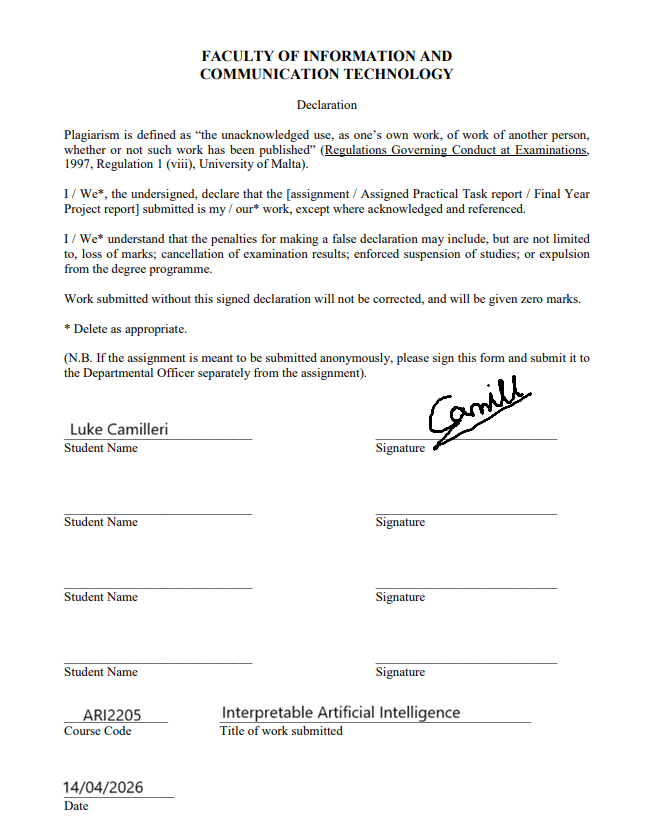

In [13]:
from IPython.display import Image, display

display(Image(filename='form.png'))
